In [8]:
import localcider
import protfasta
import glob
import pandas as pd
import numpy as np
import re
import scipy
from scipy import stats
import matplotlib.pyplot as plt
from collections import defaultdict 
from Bio.Seq import Seq


In [9]:
masterDF = pd.read_csv('../Data/Processed/SC_Glucose_Ratio_MasterDF_20210128_withSeqFeatures.csv')
maxActivity = max(masterDF.Activity_SCglucose)

In [10]:
# Define WT AD DF

WTindx  = [20679,]


# # Define the Scer WT tiles for comparison
# indx = (Orthologs_DF.SpeciesNames =='Saccharomycotina_sp|P03069|GCN4_YEAST')&(Orthologs_DF.Activity>0)
# ScertempDF = Orthologs_DF[indx]
# ScertempDF = ScertempDF.sort_values(by='NativeLocation',ascending=True)
# ScertempDF

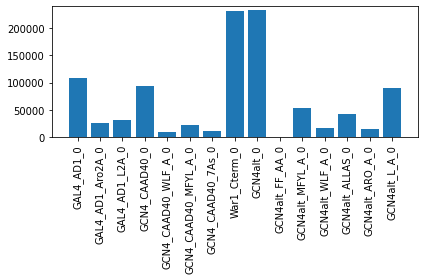

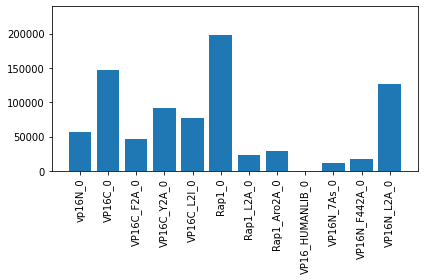

There is a design error in VP16N_L2A--the F is alo an A--it is really 7As


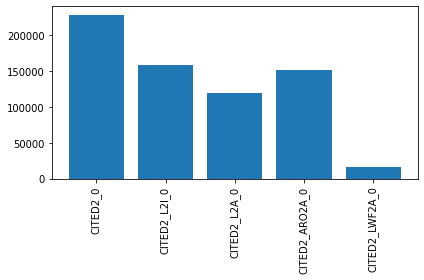

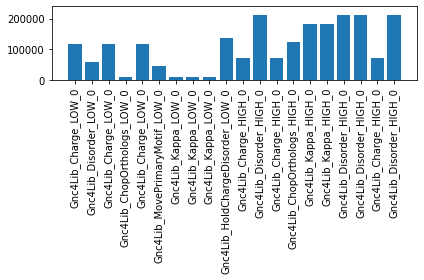

In [11]:
Controls = masterDF[-52:]
names= []
activities = defaultdict()
for i,row in Controls.iterrows():
    names.append( row['Name'])
    activities[row['Name']]= (row.Activity_SCglucose)
    
def findMutant(ad,mutname,cols=['shortname', 'MutName']):
    indx = (masterDF[ad]==1)
    tempDF = masterDF[indx]
    for i, entry in tempDF.iterrows():
        tempname = entry.MutName
        hits = re.search(mutname,tempname)
        if hits:
            print(entry[cols])
            
def plotBarGraph(tempSet,title=''):
    names = tempSet
    values = [activities[i] for i in names]
    plt.bar(range(0,len(values)),values)
    plt.xticks(range(0,len(values)),names,rotation=90)
    plt.ylim([0,maxActivity]),plt.tight_layout()
    plt.savefig('Figures/Barchart_'+title+'.pdf')
    plt.show()
    
plotBarGraph(names[0:15],'Yeast ADs')

# plotBarGraph(names[6:14],'Gcn4 CAAD Alternative')

plotBarGraph(names[15:27],'VP16')
print('There is a design error in VP16N_L2A--the F is alo an A--it is really 7As' )

# plotBarGraph(names[loc[7,20,21,22]],'Other Yeast ADs')


plotBarGraph(names[27:32],'Cited2')

plotBarGraph(names[32:53],'Gcn4')



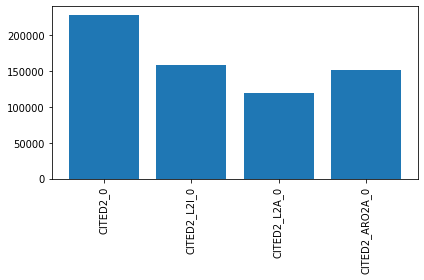

,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,ADseq,Name,ArrayDNA,Activity_SCglucose,SCglucose_TotalReads,Start,Recovered,...,V,W,Y,Aromatics,WFYL,Kappa,Omega,OmegaWFY_DE,OmegaWFYL_DE,Disorder
20679,20679,20679,0,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,GAL4_AD1_0,TCTACTATTCCATTGGACTTTATGCCAAGAGATGCTTTGCATGGAT...,108798.491795,282.0,0,True,...,0,1,0,5,9,0.378734,0.062722,0.229268,0.207893,0.512025
20680,20680,20680,1,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,GAL4_AD1_Aro2A_0,TCTACTATTCCATTGGATGCTATGCCAAGAGATGCTTTGCATGGTG...,26914.868002,1018.0,0,True,...,0,0,0,0,4,0.378734,0.062722,0.301292,0.354044,0.813200
20681,20681,20681,2,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,GAL4_AD1_L2A_0,TCTACTATTCCAGCTGACTTTATGCCAAGAGATGCTGCTCATGGAT...,31312.937583,1478.0,0,True,...,0,1,0,5,5,0.378734,0.062722,0.229268,0.229268,0.710950
20682,20682,20682,3,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,94467.880401,1975.0,0,True,...,2,1,1,4,7,0.155450,0.038449,0.136322,0.082456,0.496175
20683,20683,20683,4,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGGAAGATA...,9821.877940,728.0,0,True,...,2,0,1,2,4,0.155450,0.038449,0.133989,0.101638,0.711550
20684,20684,20684,5,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,22143.923893,1369.0,0,True,...,2,1,0,2,4,0.155450,0.038449,0.168466,0.178038,0.698100
20685,20685,20685,6,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,12423.058415,4600.0,0,True,...,2,0,0,0,1,0.155450,0.038449,0.090941,0.131243,0.892075
20686,20686,20686,7,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,CCATCTCCATCTTCTTCTGTTGATAATTTGAATGATTATTTGACTG...,231146.704122,3511.0,0,True,...,2,2,1,5,10,0.171292,0.286703,0.084722,0.062601,0.290500
20687,20687,20687,8,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,GCN4alt_0,GATGATGCTGTTGTTGAATCATTCTTCTCTTCTTCTACTGATTCTA...,232314.568388,343.0,0,True,...,2,1,1,6,8,0.137166,0.137907,0.125049,0.090405,0.488175
20688,20688,20688,9,DDAVVESAASSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,GCN4alt_FF_AA_0,GATGATGCTGTTGTTGAATCTGCTGCTTCTTCTTCTACTGATTCTA...,0.000000,0.0,0,False,...,2,1,1,4,6,0.137166,0.137907,0.116946,0.082471,0.626425


In [12]:
plotBarGraph(names[27:31],'Cited2')

Controls

In [13]:
len('DDAVVESFFSSSTD')

14